## 8.10 양자 경제물리학 — 경제 예측을 위한 양자 신경망(QNN)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.circuit import Parameter
from qiskit.primitives import StatevectorSampler  # 호환성 수정: V1 Sampler → V2 StatevectorSampler
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.connectors import TorchConnector
import matplotlib.pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 양자회로 정의
num_qubits = 4
params = [Parameter(f'theta_{i}') for i in range(num_qubits)]
qc = QuantumCircuit(num_qubits)

for i in range(num_qubits):
    qc.rx(params[i], i)

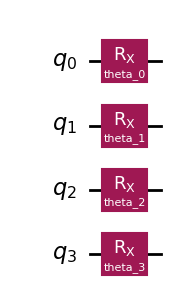

In [3]:
# 회로 시각화
qc.draw('mpl')
plt.show()

In [4]:
# 시뮬레이터와 샘플러 초기화
simulator = AerSimulator()
sampler = StatevectorSampler()  # 호환성 수정: V2 샘플러

In [5]:
# QNN 정의
qnn = SamplerQNN(circuit=qc, input_params=params, sampler=sampler)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


In [6]:
# PyTorch 모델 정의
class QuantumNeuralNetwork(nn.Module):
    def __init__(self, qnn):
        super(QuantumNeuralNetwork, self).__init__()
        self.qnn = TorchConnector(qnn)

    def forward(self, x):
        return self.qnn(x)

In [7]:
# 모델 인스턴스화
model = QuantumNeuralNetwork(qnn)

In [8]:
# 합성 데이터 생성
X_train = torch.rand((32, num_qubits))
y_train = torch.rand((32, 1))

In [9]:
# 손실 함수와 옵티마이저 정의
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
# 학습 루프
epochs = 10
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train)
    # 호환성: QNN 출력 차원과 목표 차원을 맞춤
    if outputs.shape[-1] != y_train.shape[-1]:
        outputs = outputs[:, :1]
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")

Epoch 1/10, Loss: 0.14331597089767456
Epoch 2/10, Loss: 0.14458680152893066
Epoch 3/10, Loss: 0.14425970613956451
Epoch 4/10, Loss: 0.14408518373966217
Epoch 5/10, Loss: 0.1443944275379181
Epoch 6/10, Loss: 0.14553803205490112
Epoch 7/10, Loss: 0.1455424726009369
Epoch 8/10, Loss: 0.1426154375076294
Epoch 9/10, Loss: 0.14794233441352844
Epoch 10/10, Loss: 0.147007018327713
